# Transformer Encoder (Transformer) - 20 Newsgroups Classification

This project implements a compact Transformer encoder for multi-class text classification on the 20 Newsgroups dataset. The model replaces recurrent sequence processing with self-attention, positional embeddings, residual connections, layer normalization, and a feed-forward network. Integer token sequences are used as model inputs to keep preprocessing and inference memory-efficient.

## 1. Import Required Libraries

Import the libraries required for dataset loading, text preprocessing, model development, visualization and evaluation.

In [1]:
import os
import logging
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras.layers import Input, Embedding, Dense, Dropout, Layer, LayerNormalization, MultiHeadAttention, TextVectorization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import AdamW

tf.get_logger().setLevel(logging.ERROR)
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


## 2. Load the 20 Newsgroups Dataset

Load the standard 20 Newsgroups train and test splits and create a stratified validation split from the training data.

In [2]:
newsgroups_train = fetch_20newsgroups(
    subset="train",
    remove=("headers", "footers", "quotes"),
    shuffle=True,
    random_state=42
)
newsgroups_test = fetch_20newsgroups(
    subset="test",
    remove=("headers", "footers", "quotes"),
    shuffle=False
)

train_texts = np.array(newsgroups_train.data, dtype=object)
train_labels = np.array(newsgroups_train.target, dtype=np.int32)
test_texts = np.array(newsgroups_test.data, dtype=object)
test_labels = np.array(newsgroups_test.target, dtype=np.int32)
class_names = newsgroups_train.target_names

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts, train_labels, test_size=0.10, random_state=42, stratify=train_labels
)

print("Training Samples:", len(train_texts))
print("Validation Samples:", len(val_texts))
print("Test Samples:", len(test_texts))
print("Number of Classes:", len(class_names))

Training Samples: 10182
Validation Samples: 1132
Test Samples: 7532
Number of Classes: 20


## 3. Explore the Dataset

Inspect class distribution, approximate document lengths, and representative documents before vectorization.

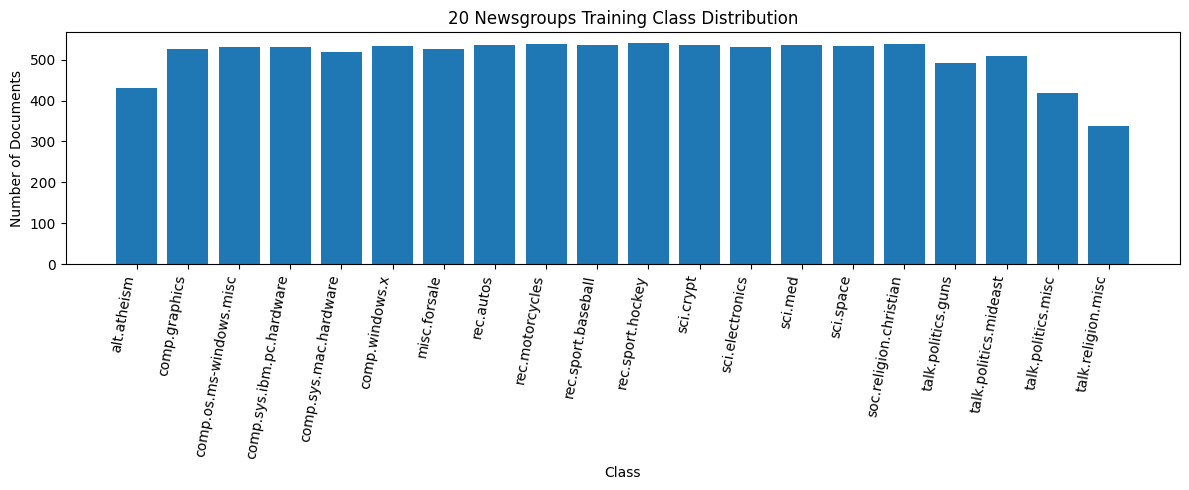

Class: alt.atheism

Actually, the story goes that Lucifer refused to bow before MAN as 
God commanded him to.  Lucifer was devoted to God.

Oh yeah, there is nothing in Genesis that says the snake was anything
more than a snake (well, a talking one...had legs at the time, too).

I don't think pointing out contradictions in STORIES is the best way
to show the error in theology:  if they think a supernatural entity
kicked the first humans out of paradise because they bit into a
fruit that gave them special powers...well, they might not respond
well to reason and logic.  :^)

Class: comp.graphics
Has anybody made a converter from irit's .irt or .dat format to
 .pov format ?

Thanks!


Class: comp.os.ms-windows.misc
Hi all,

I have a DLL in which I Register a class and create a window of that
class type.  Both calls require a module instance handle, hInstance.

Petzold's 3.1 book says that it is best to use the module instance
handle of the calling program, not the module instance handle o

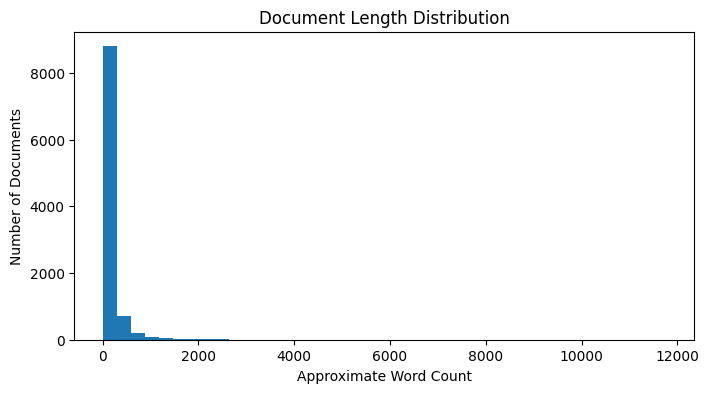

In [3]:
classes, counts = np.unique(train_labels, return_counts=True)
plt.figure(figsize=(12,5))
plt.bar(classes, counts)
plt.xlabel("Class")
plt.ylabel("Number of Documents")
plt.title("20 Newsgroups Training Class Distribution")
plt.xticks(classes, class_names, rotation=80, ha="right")
plt.tight_layout()
plt.show()

for label in range(min(4, len(class_names))):
    idx = np.where(train_labels == label)[0][0]
    print("="*100)
    print("Class:", class_names[label])
    print(train_texts[idx][:700])
    print()

sample_lengths = [len(text.split()) for text in train_texts[:10000]]
plt.figure(figsize=(8,4))
plt.hist(sample_lengths, bins=40)
plt.xlabel("Approximate Word Count")
plt.ylabel("Number of Documents")
plt.title("Document Length Distribution")
plt.show()

## 4. Preprocess the Text

Build the vocabulary from the training documents and convert every split into fixed-length integer token sequences.

In [4]:
max_tokens = 20000
sequence_length = 128

vectorizer = TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=sequence_length,
    standardize="lower_and_strip_punctuation"
)
vectorizer.adapt(tf.data.Dataset.from_tensor_slices(train_texts).batch(256))

vocabulary_size = len(vectorizer.get_vocabulary())

x_train = vectorizer(tf.constant(train_texts)).numpy().astype(np.int32)
x_val = vectorizer(tf.constant(val_texts)).numpy().astype(np.int32)
x_test = vectorizer(tf.constant(test_texts)).numpy().astype(np.int32)

print("Vocabulary Size:", vocabulary_size)
print("Sequence Length:", sequence_length)
print("Training Token Shape:", x_train.shape)
print("Validation Token Shape:", x_val.shape)
print("Test Token Shape:", x_test.shape)

Vocabulary Size: 20000
Sequence Length: 128
Training Token Shape: (10182, 128)
Validation Token Shape: (1132, 128)
Test Token Shape: (7532, 128)


## 5. Create TensorFlow Input Pipelines

Create integer-token datasets for mini-batch training and evaluation so that text conversion is not repeated during every step.

In [5]:
batch_size = 64

train_data = tf.data.Dataset.from_tensor_slices((x_train, train_labels)).shuffle(
    len(x_train), seed=42, reshuffle_each_iteration=True
).batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_data = tf.data.Dataset.from_tensor_slices((x_val, val_labels)).batch(
    batch_size
).prefetch(tf.data.AUTOTUNE)

test_data = tf.data.Dataset.from_tensor_slices((x_test, test_labels)).batch(
    batch_size
).prefetch(tf.data.AUTOTUNE)

print("Batch Size:", batch_size)

Batch Size: 64


## 6. Build the Transformer Encoder

Construct token and positional embeddings, multi-head self-attention, residual connections, layer normalization, and a feed-forward network.

In [7]:
embedding_dim = 96
num_heads = 4
ff_dim = 192
dropout_rate = 0.30


class TokenAndPositionEmbedding(Layer):
    def __init__(
        self,
        vocab_size,
        seq_len,
        dim,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.token_embedding = Embedding(
            input_dim=vocab_size,
            output_dim=dim
        )

        self.position_embedding = Embedding(
            input_dim=seq_len,
            output_dim=dim
        )

        self.seq_len = seq_len

    def call(self, inputs):
        positions = tf.range(
            start=0,
            limit=self.seq_len,
            delta=1
        )

        token_embeddings = self.token_embedding(inputs)
        position_embeddings = self.position_embedding(positions)

        return token_embeddings + position_embeddings


class MaskedGlobalAveragePooling(Layer):
    def call(self, inputs):
        tokens, mask = inputs

        mask = tf.cast(
            tf.expand_dims(mask, axis=-1),
            tokens.dtype
        )

        summed = tf.reduce_sum(
            tokens * mask,
            axis=1
        )

        counts = tf.reduce_sum(
            mask,
            axis=1
        )

        return summed / tf.maximum(
            counts,
            tf.keras.backend.epsilon()
        )


class TransformerEncoder(Layer):
    def __init__(
        self,
        dim,
        heads,
        ff_dim,
        dropout=0.1,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.attention = MultiHeadAttention(
            num_heads=heads,
            key_dim=dim // heads,
            dropout=dropout
        )

        self.ffn = tf.keras.Sequential([
            Dense(
                ff_dim,
                activation="gelu"
            ),
            Dropout(dropout),
            Dense(dim)
        ])

        self.norm1 = LayerNormalization(
            epsilon=1e-6
        )

        self.norm2 = LayerNormalization(
            epsilon=1e-6
        )

        self.dropout1 = Dropout(dropout)
        self.dropout2 = Dropout(dropout)

    def call(
        self,
        inputs,
        attention_mask=None,
        training=False
    ):
        attention_output = self.attention(
            query=inputs,
            value=inputs,
            key=inputs,
            attention_mask=attention_mask,
            training=training
        )

        attention_output = self.dropout1(
            attention_output,
            training=training
        )

        x = self.norm1(
            inputs + attention_output
        )

        feed_forward_output = self.ffn(
            x,
            training=training
        )

        feed_forward_output = self.dropout2(
            feed_forward_output,
            training=training
        )

        return self.norm2(
            x + feed_forward_output
        )


token_input = Input(
    shape=(sequence_length,),
    dtype=tf.int32,
    name="token_input"
)

# Use Keras operations for symbolic tensors.
padding_mask = tf.keras.ops.not_equal(
    token_input,
    0
)

attention_mask = tf.keras.ops.logical_and(
    tf.keras.ops.expand_dims(
        padding_mask,
        axis=1
    ),
    tf.keras.ops.expand_dims(
        padding_mask,
        axis=2
    )
)

x = TokenAndPositionEmbedding(
    vocabulary_size,
    sequence_length,
    embedding_dim,
    name="token_position_embedding"
)(token_input)

x = TransformerEncoder(
    embedding_dim,
    num_heads,
    ff_dim,
    dropout_rate,
    name="transformer_encoder"
)(
    x,
    attention_mask=attention_mask
)

x = MaskedGlobalAveragePooling()(
    [
        x,
        padding_mask
    ]
)

x = Dropout(
    dropout_rate
)(x)

x = Dense(
    96,
    activation="gelu"
)(x)

x = Dropout(
    dropout_rate
)(x)

output = Dense(
    len(class_names),
    activation="softmax",
    name="classifier"
)(x)

transformer_model = Model(
    inputs=token_input,
    outputs=output,
    name="20Newsgroups_Transformer_Classifier"
)

transformer_model.compile(
    optimizer=AdamW(
        learning_rate=5e-4,
        weight_decay=1e-4
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

transformer_model.summary()

Model: "20Newsgroups_Transformer_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ token_input         │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 128)       │          0 │ token_input[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims         │ (None, 1, 128)    │          0 │ not_equal[0][0]   │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims_1       │ (None, 128, 1)    │          0 │ not_equal[0][0]   │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_position_emb… │ (None, 128, 96)   │  1,932,288 │ token_input[0][0] │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_and         │ (None, 128, 128)  │          0 │ expand_dims[0][0… │
│ (LogicalAnd)        │                   │            │ expand_dims_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encoder │ (None, 128, 96)   │     74,784 │ token_position_e… │
│ (TransformerEncode… │                   │            │ logical_and[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masked_global_aver… │ (None, 96)        │          0 │ transformer_enco… │
│ (MaskedGlobalAvera… │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 96)        │          0 │ masked_global_av… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 96)        │      9,312 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 96)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classifier (Dense)  │ (None, 20)        │      1,940 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,018,324 (7.70 MB)

 Trainable params: 2,018,324 (7.70 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Train the Transformer

Train the encoder while monitoring validation loss. Dropout and AdamW regularization reduce the overfitting seen in the earlier run.

In [8]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = transformer_model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    shuffle=False,
    callbacks=[early_stopping]
)

best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
print("Best Epoch:", best_epoch)
print(f"Best Validation Loss: {history.history['val_loss'][best_epoch-1]:.4f}")
print(f"Best Validation Accuracy: {history.history['val_accuracy'][best_epoch-1]:.4f}")

Epoch 1/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 22s 66ms/step - accuracy: 0.1428 - loss: 2.8033 - val_accuracy: 0.3180 - val_loss: 2.3082
Epoch 2/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4232 - loss: 1.8464 - val_accuracy: 0.4929 - val_loss: 1.5789
Epoch 3/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6869 - loss: 1.0273 - val_accuracy: 0.6378 - val_loss: 1.2195
Epoch 4/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8201 - loss: 0.5966 - val_accuracy: 0.6458 - val_loss: 1.2883
Epoch 5/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8908 - loss: 0.3656 - val_accuracy: 0.6970 - val_loss: 1.3671
Epoch 6/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9273 - loss: 0.2585 - val_accuracy: 0.6829 - val_loss: 1.4455
Best Epoch: 3
Best Validation Loss: 1.2195
Best Validation Accuracy: 0.6378


## 8. Training Curves

Visualize training and validation accuracy and loss.

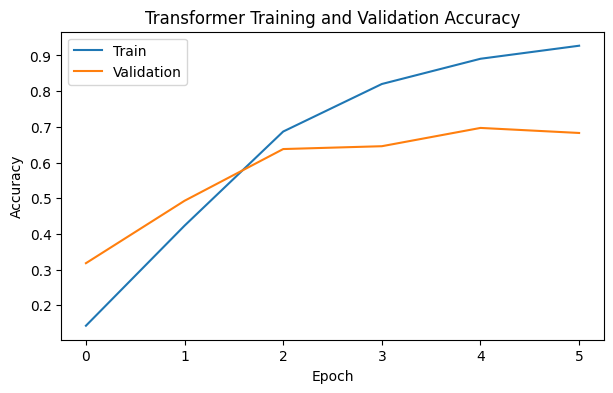

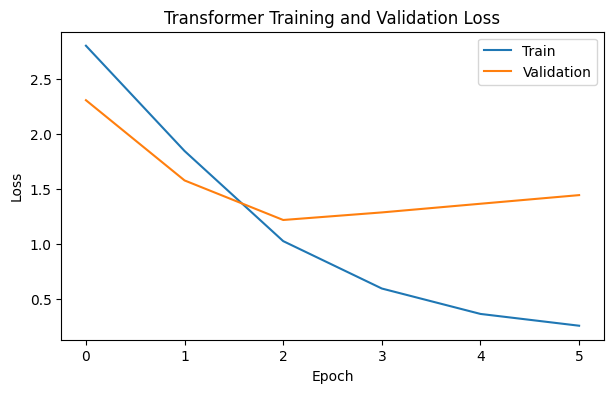

In [9]:
plt.figure(figsize=(7,4))
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transformer Training and Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transformer Training and Validation Loss")
plt.legend()
plt.show()

## 9. Evaluate the Model

Evaluate the best model on the held-out test set using small batches.

In [10]:
test_loss, test_accuracy = transformer_model.evaluate(
    x_test,
    test_labels,
    batch_size=32,
    verbose=1
)

probabilities = transformer_model.predict(
    x_test,
    batch_size=32,
    verbose=1
)

predictions = np.argmax(probabilities, axis=1)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

236/236 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5608 - loss: 1.5486
236/236 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Test Loss: 1.5486
Test Accuracy: 0.5608


## 10. Classification Report

Measure precision, recall and F1-score across all twenty categories.

In [11]:
print(classification_report(
    test_labels,
    predictions,
    target_names=class_names,
    digits=4
))

                          precision    recall  f1-score   support

             alt.atheism     0.3720    0.3417    0.3562       319
           comp.graphics     0.6337    0.4447    0.5227       389
 comp.os.ms-windows.misc     0.4267    0.6574    0.5175       394
comp.sys.ibm.pc.hardware     0.6104    0.4796    0.5371       392
   comp.sys.mac.hardware     0.6989    0.5065    0.5873       385
          comp.windows.x     0.7798    0.5468    0.6429       395
            misc.forsale     0.6821    0.7923    0.7331       390
               rec.autos     0.6828    0.4621    0.5512       396
         rec.motorcycles     0.6466    0.5930    0.6186       398
      rec.sport.baseball     0.7610    0.6096    0.6769       397
        rec.sport.hockey     0.7883    0.8120    0.8000       399
               sci.crypt     0.7217    0.6288    0.6721       396
         sci.electronics     0.4171    0.4097    0.4134       393
                 sci.med     0.7599    0.5833    0.6600       396
         

## 11. Confusion Matrix

Visualize class-level prediction errors.

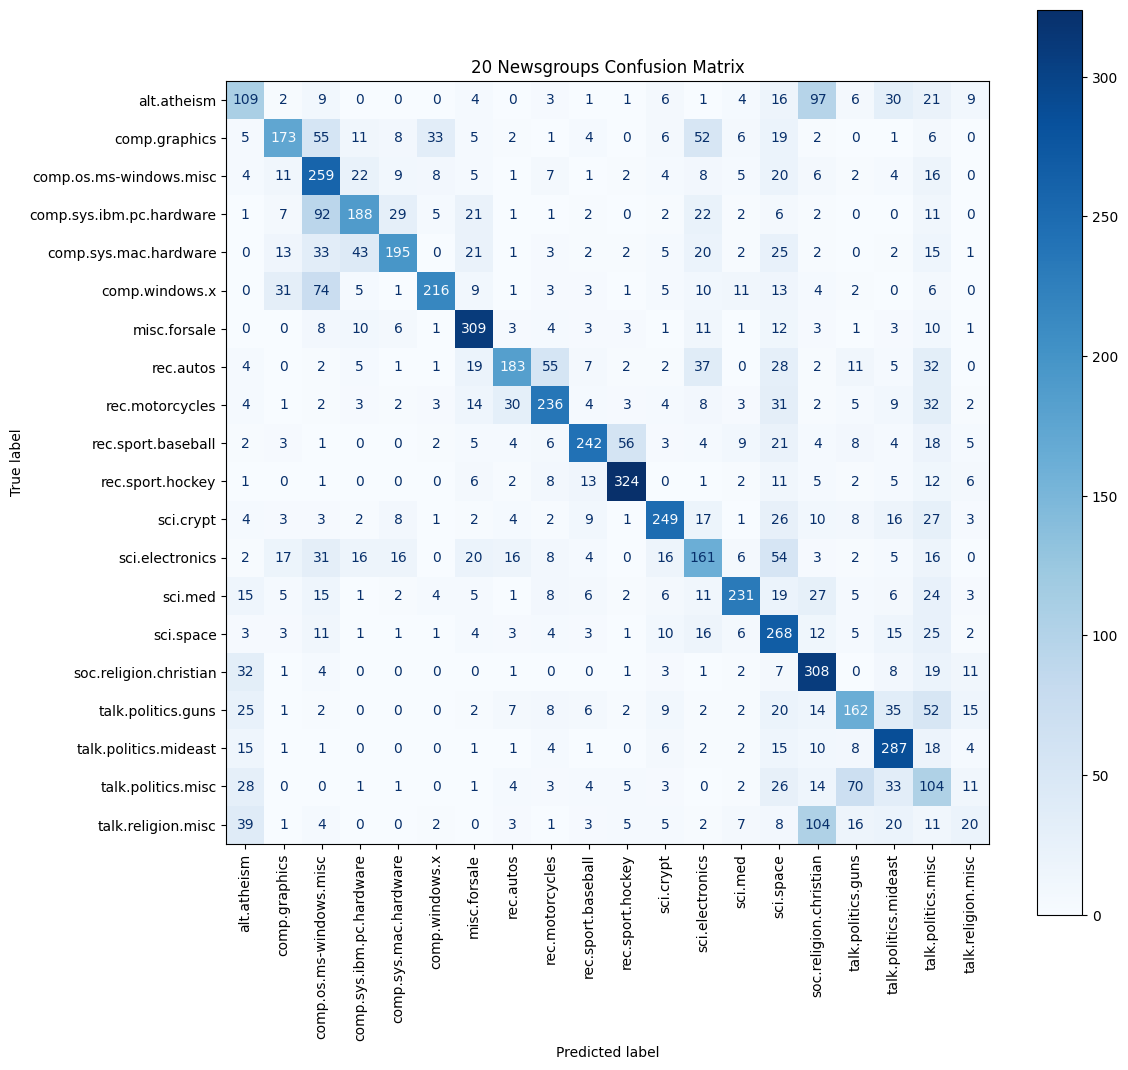

In [12]:
cm = confusion_matrix(test_labels, predictions)
fig, ax = plt.subplots(figsize=(12,11))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
).plot(ax=ax, cmap="Blues", xticks_rotation=90, values_format="d")
plt.title("20 Newsgroups Confusion Matrix")
plt.tight_layout()
plt.show()

## 12. Error Analysis

Inspect representative misclassified documents.

In [13]:
misclassified = np.where(predictions != test_labels)[0]
for idx in misclassified[:8]:
    print("="*100)
    print("True Label     :", class_names[test_labels[idx]])
    print("Predicted Label:", class_names[predictions[idx]])
    print("Document:")
    print(test_texts[idx][:1200])
    print()

True Label     : sci.space
Predicted Label: comp.windows.x
Document:
I'm afraid I was not able to find the GIFs... is the list 
updated weekly, perhaps, or am I just missing something?

True Label     : talk.politics.misc
Predicted Label: alt.atheism
Document:
: >
: >Unless, of course, the problem is that homosexuality is a form
: >of mental disorder, caused by childhood sexual abuse, as a number of
: >recent works suggest.
: 
: Which number is that?  Zero?

The only time I have heard mention of such a mechanism is
with respect to FEMALE homosexuality resulting from HETEROSEXUAL
childhood abuse.
(and this as only one of several factors affecting the same person)

As Mr Cramer appears to concentrate on MALE homosexuality
I doubt this is what he has in mind.

--

True Label     : comp.windows.x
Predicted Label: misc.forsale
Document:
Just opened up the distribution.


True Label     : rec.autos
Predicted Label: talk.politics.guns
Document:

Carrying in the glove box is not covered...I'm 

## 13. Key Findings



## 14. Conclusion

